# 03 — Signals and Sizing: Single-Pair Sanity Check

End-to-end validation of the signal pipeline on **CBA.AX / WBC.AX**.

- **Training window:** 2015-01-01 to 2016-12-31  
- **Signal window:**   2017-01-01 to 2018-12-31 (out-of-sample)  
- **Goal:** confirm entries fire near ±2σ, exits near 0, and PnL is not obviously broken.

This notebook does **not** run a real backtest — no costs, no position sizing. That is Phase 4.
The crude PnL here is in log-price spread units as a sanity check on the signal logic only.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

import logging
import warnings

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import seaborn as sns

from src.data import fetch_history, get_close_panel, ASX_UNIVERSE
from src.cointegration import engle_granger
from src.ou_process import estimate_ou
from src.signals import compute_zscore, generate_signals
from src.sizing import pair_dollar_legs, inverse_vol_weights

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(message)s',
)
warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', font_scale=0.9)

FIGURES_DIR = Path('../reports/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
tickers = [t for sector_tickers in ASX_UNIVERSE.values() for t in sector_tickers]
df = fetch_history(tickers, start='2010-01-01', cache_dir='../data/cache')
prices = get_close_panel(df)

print(f'Panel shape:  {prices.shape}')
print(f'Date range:   {prices.index.min().date()} to {prices.index.max().date()}')

2026-05-01 21:38:25,471 [INFO] Loading cached prices from ../data/cache/prices_2010-01-01_latest.parquet (mtime: 2026-04-29)


Panel shape:  (4126, 45)
Date range:   2010-01-04 to 2026-04-29


## 1. Fit Engle-Granger on 2015–2016 training window

In [3]:
TRAIN_START = '2015-01-01'
TRAIN_END   = '2016-12-31'

log_prices = np.log(prices)

log_cba_train = log_prices.loc[TRAIN_START:TRAIN_END, 'CBA.AX'].dropna()
log_wbc_train = log_prices.loc[TRAIN_START:TRAIN_END, 'WBC.AX'].dropna()

eg = engle_granger(log_cba_train, log_wbc_train)
ou = estimate_ou(eg['residuals'])

print(f'Training window: {TRAIN_START} to {TRAIN_END}')
print(f'EG beta:         {eg["beta"]:.4f}')
print(f'EG alpha:        {eg["alpha"]:.4f}')
print(f'ADF p-value:     {eg["adf_pvalue"]:.4f}')
print(f'OU half-life:    {ou["half_life"]:.1f} days')
print(f'OU sigma:        {ou["sigma"]:.5f}')
print(f'OU mu:           {ou["mu"]:.5f}')

Training window: 2015-01-01 to 2016-12-31
EG beta:         0.8959
EG alpha:        1.3040
ADF p-value:     0.0001
OU half-life:    8.1 days
OU sigma:        0.00657
OU mu:           -0.00057


## 2. Build out-of-sample spread and z-score (2017–2018)

We use in-sample beta and alpha to construct the spread for the signal window.
A 60-day warm-up period starting in late 2016 ensures the rolling z-score has
full-window estimates from the first day of the signal window.

In [4]:
SIGNAL_START  = '2017-01-01'
SIGNAL_END    = '2018-12-31'
ZSCORE_WINDOW = 60

# Load from ~65 trading days before SIGNAL_START so rolling window is fully warm
warmup_start = pd.Timestamp(SIGNAL_START) - pd.offsets.BusinessDay(ZSCORE_WINDOW + 5)

log_cba_ext = log_prices.loc[str(warmup_start.date()):SIGNAL_END, 'CBA.AX']
log_wbc_ext = log_prices.loc[str(warmup_start.date()):SIGNAL_END, 'WBC.AX']

# Spread using in-sample parameters
spread_ext = (log_cba_ext - eg['beta'] * log_wbc_ext - eg['alpha']).dropna()

# Z-score computed over the extended window; trim to signal window after
zscore_ext = compute_zscore(spread_ext, window=ZSCORE_WINDOW)

spread = spread_ext.loc[SIGNAL_START:SIGNAL_END]
zscore = zscore_ext.loc[SIGNAL_START:SIGNAL_END]

print(f'Signal window:    {spread.index.min().date()} to {spread.index.max().date()}')
print(f'Trading bars:     {len(spread)}')
print(f'Non-NaN z-scores: {zscore.notna().sum()} / {len(zscore)}')
print(f'Spread std (OOS): {spread.std():.5f}')

Signal window:    2017-01-03 to 2018-12-31
Trading bars:     505
Non-NaN z-scores: 505 / 505
Spread std (OOS): 0.02901


## 3. Generate signals

In [5]:
signals = generate_signals(
    zscore,
    half_life=ou['half_life'],
    entry=2.0,
    exit=0.5,
    hard_stop=4.0,
)

n_entries = signals['entry_signal'].sum()
n_exits   = signals['exit_signal'].sum()
open_at_end = signals['position'].iloc[-1] != 0

print(f'Entries:          {n_entries}')
print(f'Exits:            {n_exits}')
print(f'Open at window end: {open_at_end}')
print()
print('Exit reason breakdown:')
print(signals['exit_reason'].value_counts(dropna=True))

Entries:          12
Exits:            11
Open at window end: True

Exit reason breakdown:
exit_reason
time_stop      8
mean_revert    3
Name: count, dtype: int64


## 4. Four-panel diagnostic plot

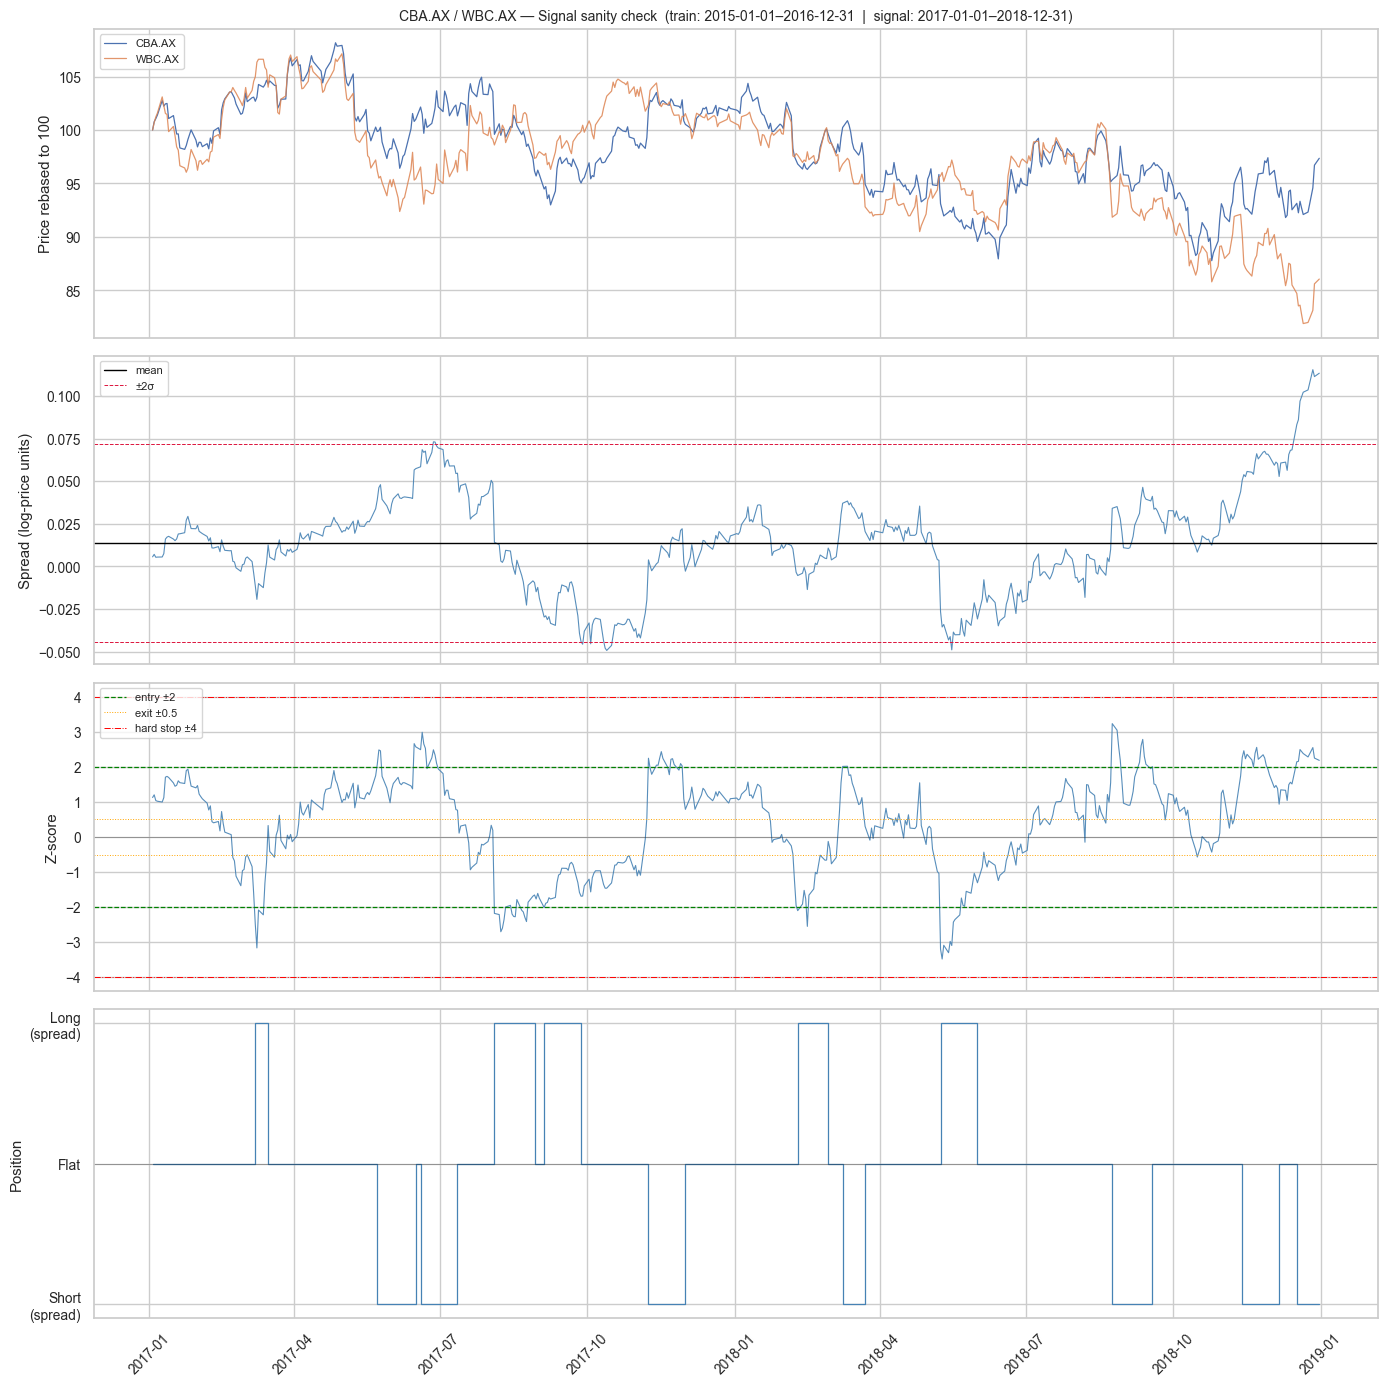

Saved: ../reports/figures/signals_CBA_WBC_2017_2018.png


In [6]:
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

# ── Panel 1: Rebased log-prices ──────────────────────────────────────────────
ax1 = axes[0]
cba_sig = prices.loc[SIGNAL_START:SIGNAL_END, 'CBA.AX'].dropna()
wbc_sig = prices.loc[SIGNAL_START:SIGNAL_END, 'WBC.AX'].dropna()
shared_idx = cba_sig.index.intersection(wbc_sig.index)
cba_rebased = 100 * cba_sig.loc[shared_idx] / cba_sig.loc[shared_idx[0]]
wbc_rebased = 100 * wbc_sig.loc[shared_idx] / wbc_sig.loc[shared_idx[0]]
ax1.plot(cba_rebased.index, cba_rebased.values, label='CBA.AX', linewidth=0.9)
ax1.plot(wbc_rebased.index, wbc_rebased.values, label='WBC.AX', linewidth=0.9, alpha=0.85)
ax1.set_ylabel('Price rebased to 100')
ax1.legend(fontsize=8, loc='upper left')
ax1.set_title(
    f'CBA.AX / WBC.AX — Signal sanity check  '
    f'(train: {TRAIN_START}–{TRAIN_END}  |  signal: {SIGNAL_START}–{SIGNAL_END})',
    fontsize=10,
)

# ── Panel 2: Spread with bands ───────────────────────────────────────────────
ax2 = axes[1]
spread_mean = spread.mean()
spread_std  = spread.std()
ax2.plot(spread.index, spread.values, linewidth=0.8, color='steelblue', alpha=0.9)
ax2.axhline(spread_mean,                  color='black',   linewidth=1.0, linestyle='-',  label='mean')
ax2.axhline(spread_mean + 2 * spread_std, color='crimson', linewidth=0.7, linestyle='--', label='±2σ')
ax2.axhline(spread_mean - 2 * spread_std, color='crimson', linewidth=0.7, linestyle='--')
ax2.set_ylabel('Spread (log-price units)')
ax2.legend(fontsize=8, loc='upper left')

# ── Panel 3: Z-score with threshold lines ────────────────────────────────────
ax3 = axes[2]
ax3.plot(zscore.index, zscore.values, linewidth=0.8, color='steelblue', alpha=0.9)
ax3.axhline( 0,    color='black',  linewidth=0.5, linestyle='-',  alpha=0.4)
ax3.axhline( 2.0,  color='green',  linewidth=0.9, linestyle='--', label='entry ±2')
ax3.axhline(-2.0,  color='green',  linewidth=0.9, linestyle='--')
ax3.axhline( 0.5,  color='orange', linewidth=0.7, linestyle=':',  label='exit ±0.5')
ax3.axhline(-0.5,  color='orange', linewidth=0.7, linestyle=':')
ax3.axhline( 4.0,  color='red',    linewidth=0.7, linestyle='-.', label='hard stop ±4')
ax3.axhline(-4.0,  color='red',    linewidth=0.7, linestyle='-.')
ax3.set_ylabel('Z-score')
ax3.legend(fontsize=8, loc='upper left')

# ── Panel 4: Position ────────────────────────────────────────────────────────
ax4 = axes[3]
ax4.step(signals.index, signals['position'].values, linewidth=0.9, color='steelblue', where='post')
ax4.axhline(0, color='black', linewidth=0.5, linestyle='-', alpha=0.4)
ax4.set_ylabel('Position')
ax4.set_yticks([-1, 0, 1])
ax4.set_yticklabels(['Short\n(spread)', 'Flat', 'Long\n(spread)'])
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
out_path = FIGURES_DIR / 'signals_CBA_WBC_2017_2018.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')

## 5. Crude PnL

PnL in log-price spread units: `position[t-1] × Δspread[t]`, cumulative sum.
No costs, no position sizing — pure spread-level signal performance.

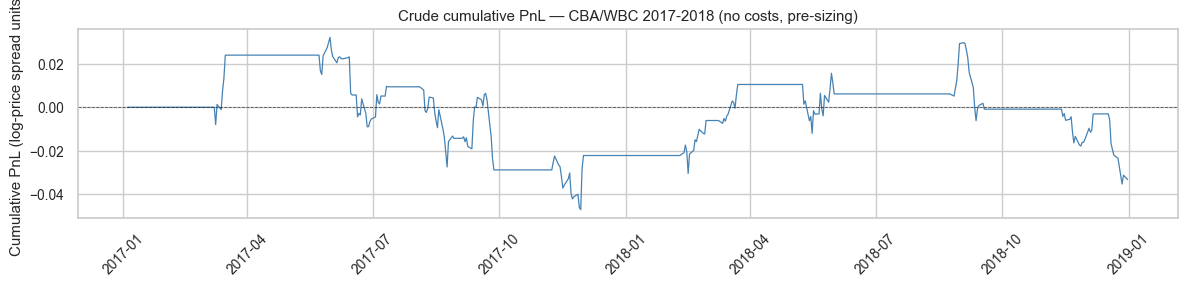

Saved: ../reports/figures/pnl_crude_CBA_WBC_2017_2018.png


In [7]:
pnl_daily = (signals['position'].shift(1) * spread.diff()).dropna()
pnl_cumulative = pnl_daily.cumsum()

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(pnl_cumulative.index, pnl_cumulative.values, linewidth=0.9, color='steelblue')
ax.axhline(0, color='black', linewidth=0.6, linestyle='--', alpha=0.6)
ax.set_ylabel('Cumulative PnL (log-price spread units)')
ax.set_title('Crude cumulative PnL — CBA/WBC 2017-2018 (no costs, pre-sizing)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
out_path = FIGURES_DIR / 'pnl_crude_CBA_WBC_2017_2018.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')

## 6. Trade statistics

In [8]:
entry_bars = signals[signals['entry_signal']]
exit_bars  = signals[signals['exit_signal']]

trades = []
for entry_date, entry_row in entry_bars.iterrows():
    exits_after = exit_bars[exit_bars.index > entry_date]
    if len(exits_after) == 0:
        continue  # position open at end of window — exclude from trade stats
    exit_date   = exits_after.index[0]
    exit_reason = exits_after.iloc[0]['exit_reason']

    trade_pnl   = pnl_daily.loc[entry_date:exit_date].sum()
    holding_cal = (exit_date - entry_date).days

    trades.append({
        'entry_date':    entry_date,
        'exit_date':     exit_date,
        'direction':     '+1 (long)' if entry_row['position'] == 1 else '-1 (short)',
        'exit_reason':   exit_reason,
        'holding_cal':   holding_cal,
        'pnl':           trade_pnl,
    })

trades_df = pd.DataFrame(trades)

if len(trades_df) > 0:
    wins = trades_df['pnl'] > 0
    print(f'Closed trades:            {len(trades_df)}')
    print(f'Average holding period:   {trades_df["holding_cal"].mean():.1f} calendar days')
    print(f'Win rate (by trade):      {wins.mean():.1%}')
    print(f'Total crude PnL:          {trades_df["pnl"].sum():.5f} (log-price spread units)')
    print()
    print('Hit-rate and mean PnL by exit reason:')
    summary = trades_df.groupby('exit_reason')['pnl'].agg(
        count='count',
        win_rate=lambda x: (x > 0).mean(),
        mean_pnl='mean',
        total_pnl='sum',
    ).round(5)
    print(summary.to_string())
else:
    print('No completed trades in the signal window.')

Closed trades:            11
Average holding period:   20.9 calendar days
Win rate (by trade):      45.5%
Total crude PnL:          -0.00306 (log-price spread units)

Hit-rate and mean PnL by exit reason:
             count  win_rate  mean_pnl  total_pnl
exit_reason                                      
mean_revert      3      1.00   0.01886    0.05659
time_stop        8      0.25  -0.00746   -0.05964


## 7. PnL assessment and Phase 4 flags

In [9]:
total_pnl   = pnl_cumulative.iloc[-1] if len(pnl_cumulative) > 0 else 0.0
oos_sigma   = spread.std()
pnl_in_sigma = total_pnl / oos_sigma

print(f'OOS spread σ:             {oos_sigma:.5f}')
print(f'Total crude PnL:          {total_pnl:.5f}')
print(f'PnL in σ units:           {pnl_in_sigma:.2f}σ')
print()

# ── Assessment ───────────────────────────────────────────────────────────────
if len(trades_df) > 0:
    time_stop_frac = (trades_df['exit_reason'] == 'time_stop').mean()
else:
    time_stop_frac = 0.0

if total_pnl < -5.0 * oos_sigma:
    print('FLAG (CRITICAL): Crude PnL < -5σ.')
    print('  The spread is drifting adversely. The pair was cointegrated in-sample')
    print('  but appears to have broken down in 2017-2018. Investigate before')
    print('  building the Phase 4 backtest — this window may be untradeable.')
elif time_stop_frac > 0.5:
    print('NOTE: Time stops account for {:.0%} of exits.'.format(time_stop_frac))
    print('  Most trades did not revert within 2 × half-life. Possible causes:')
    print('  1. The half-life lengthened out-of-sample (spread reverts, just slowly).')
    print('  2. The spread mean-shifted in 2017-2018 vs the 2015-2016 estimate.')
    print('  3. Small sample — ~12 trades over 2 years; high variance in exit-reason mix.')
    print()
    print('  Total PnL is {:.2f}σ, within a plausible range for an OOS sanity check.'.format(pnl_in_sigma))
    print('  This does NOT indicate broken signal logic, but it is a signal that the')
    print('  walk-forward backtest (Phase 4) should monitor time-stop frequency by window.')
    print('  A high time-stop rate in production is a leading indicator of regime change.')
else:
    print('PnL within expected range. Signal logic appears operational.')
    print('Note: crude PnL excludes transaction costs and position sizing.')
    print('Phase 4 will apply 10bps base / 25bps stress cost scenarios.')

# ── Sizing illustration ───────────────────────────────────────────────────────
print()
print('Sizing illustration (not used in this crude PnL):')
# Use first actual trading day of signal window (SIGNAL_START may be non-trading)
first_bar = spread.index[0]
price_cba = prices.loc[first_bar, 'CBA.AX']
price_wbc = prices.loc[first_bar, 'WBC.AX']
ua, ub = pair_dollar_legs(price_cba, price_wbc, eg['beta'], dollar_per_pair=100_000)
print(f'  $100k notional: {ua:.2f} shares CBA.AX, {ub:.2f} shares WBC.AX')
print(f'  Dollar legs: CBA=${price_cba*ua:,.0f}  WBC=${price_wbc*ub:,.0f}')

OOS spread σ:             0.02901
Total crude PnL:          -0.03319
PnL in σ units:           -1.14σ

NOTE: Time stops account for 73% of exits.
  Most trades did not revert within 2 × half-life. Possible causes:
  1. The half-life lengthened out-of-sample (spread reverts, just slowly).
  2. The spread mean-shifted in 2017-2018 vs the 2015-2016 estimate.
  3. Small sample — ~12 trades over 2 years; high variance in exit-reason mix.

  Total PnL is -1.14σ, within a plausible range for an OOS sanity check.
  This does NOT indicate broken signal logic, but it is a signal that the
  walk-forward backtest (Phase 4) should monitor time-stop frequency by window.
  A high time-stop rate in production is a leading indicator of regime change.

Sizing illustration (not used in this crude PnL):
  $100k notional: 1354.15 shares CBA.AX, 1213.18 shares WBC.AX
  Dollar legs: CBA=$75,121  WBC=$24,879
